In [346]:
import torch
import numpy as np
import os
import re

In [347]:
!unzip data.zip

Archive:  data.zip
replace data/eng-fra.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [348]:
files = os.listdir("data/names")
print(files)

['Chinese.txt', 'English.txt', 'Italian.txt', 'Czech.txt', 'Vietnamese.txt', 'Portuguese.txt', 'Irish.txt', 'French.txt', 'Scottish.txt', 'Greek.txt', 'Arabic.txt', 'Polish.txt', 'Dutch.txt', 'Japanese.txt', 'German.txt', 'Russian.txt', 'Spanish.txt', 'Korean.txt']


In [349]:
for i, f in enumerate(files):
  with open(os.path.join("data/names", f)) as file:
    l = file.readlines()
    print(f, len(l))

Chinese.txt 268
English.txt 3668
Italian.txt 709
Czech.txt 519
Vietnamese.txt 73
Portuguese.txt 74
Irish.txt 232
French.txt 277
Scottish.txt 100
Greek.txt 203
Arabic.txt 2000
Polish.txt 139
Dutch.txt 297
Japanese.txt 991
German.txt 724
Russian.txt 9408
Spanish.txt 298
Korean.txt 94


Crazy class imbalance, must stratify, but idk how much that'll work

In [350]:
names = []
labels = []
for i, f in enumerate(files):
  with open(os.path.join("data/names", f)) as file:
    l = file.readlines()
    names.extend([l[i][:-1].lower() for i in range(len(l))])
    labels.extend([i] * len(l))

print(names, labels)

['ang', 'au-yong', 'bai', 'ban', 'bao', 'bei', 'bian', 'bui', 'cai', 'cao', 'cen', 'chai', 'chaim', 'chan', 'chang', 'chao', 'che', 'chen', 'cheng', 'cheung', 'chew', 'chieu', 'chin', 'chong', 'chou', 'chu', 'cui', 'dai', 'deng', 'ding', 'dong', 'dou', 'duan', 'eng', 'fan', 'fei', 'feng', 'foong', 'fung', 'gan', 'gauk', 'geng', 'gim', 'gok', 'gong', 'guan', 'guang', 'guo', 'gwock', 'han', 'hang', 'hao', 'hew', 'hiu', 'hong', 'hor', 'hsiao', 'hua', 'huan', 'huang', 'hui', 'huie', 'huo', 'jia', 'jiang', 'jin', 'jing', 'joe', 'kang', 'kau', 'khoo', 'khu', 'kong', 'koo', 'kwan', 'kwei', 'kwong', 'lai', 'lam', 'lang', 'lau', 'law', 'lew', 'lian', 'liao', 'lim', 'lin', 'ling', 'liu', 'loh', 'long', 'loong', 'luo', 'mah', 'mai', 'mak', 'mao', 'mar', 'mei', 'meng', 'miao', 'min', 'ming', 'moy', 'mui', 'nie', 'niu', 'ou-yang', 'ow-yang', 'pan', 'pang', 'pei', 'peng', 'ping', 'qian', 'qin', 'qiu', 'quan', 'que', 'ran', 'rao', 'rong', 'ruan', 'sam', 'seah', 'see ', 'seow', 'seto', 'sha', 'shan', 

In [351]:
# check if all chars from standard charset
bad_indices = [18214, 233, 4909, 5147]
names = [elem for i, elem in enumerate(names) if i not in bad_indices]
labels = [label for i, label in enumerate(labels) if i not in bad_indices]
for i, name in enumerate(names):
  if bool(re.search(r"[^a-zA-Z-' ]", name)):
    if "," in name:
      names[i] = name.strip(",")
    print(i, name)

3941 abbà
3953 abelló
4001 airò
4036 alò
4079 azzarà
4141 bovér
4286 giùgovaz
4302 làconi
4303 laganà
4304 lagomarsìno
4318 leggièri
4319 lèmmi
4490 ré
4569 spanò
4578 tamàro
5003 rafaj1
5116 urbanek1
5238 araújo
5256 estéves
5273 magalhães
5293 romão
5302 simões
5352 dúbhshlaine
5554 bélanger
5559 béringer
5595 coté
5628 émile
5640 félix
5655 géroux
5663 guérin
5667 hébert
5692 lécuyer
5694 lefévre
5698 lémieux
5703 lévêque
5704 lévesque
5708 maçon
5790 séverin
8128 broż
8149 górka
8150 górski
8164 kamiński
8177 król
8185 marszałek
8204 róg
8217 ślązak
8218 ślusarczyk
8219 ślusarski
8220 smolák
8229 sówka
8246 wojewódka
8247 wojewódzki
8258 żuraw
9558 adlersflügel
9567 armbrüster
9579 bäcker
9581 bähr
9588 baumgärtner
9623 böhler
9624 böhm
9625 böhme
9626 böhmer
9629 bösch
9631 böttcher
9676 dürr
9693 färber
9707 förstner
9721 fürst
9727 gärtner
9747 glöckner
9760 groß
9761 große
9763 größel
9764 großel
9765 großer
9768 grünewald
9769 günther
9813 höfler
9818 hölzer
9827 hüber
9837 jä

In [352]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor

In [353]:
vocab = {}
for name in names:
  for char in name:
    if char not in vocab:
      vocab[char] = len(vocab)+1
print(vocab)

{'a': 1, 'n': 2, 'g': 3, 'u': 4, '-': 5, 'y': 6, 'o': 7, 'b': 8, 'i': 9, 'e': 10, 'c': 11, 'h': 12, 'm': 13, 'w': 14, 'd': 15, 'f': 16, 'k': 17, 'r': 18, 's': 19, 'j': 20, 'l': 21, 'p': 22, 'q': 23, ' ': 24, 't': 25, 'z': 26, 'x': 27, 'v': 28, 'à': 29, 'ó': 30, 'ò': 31, 'é': 32, "'": 33, 'ù': 34, 'ì': 35, 'è': 36, '1': 37, 'ú': 38, 'ã': 39, 'õ': 40, 'ê': 41, 'ç': 42, 'ż': 43, 'ń': 44, 'ł': 45, 'ś': 46, 'ą': 47, 'á': 48, 'ü': 49, 'ä': 50, 'ö': 51, 'ß': 52, 'í': 53, 'ñ': 54}


In [354]:
lengths = np.array([len(name) for name in names])

In [355]:
seqlen = max([len(name) for name in names])
for i, name in enumerate(names):
  names[i] = [vocab[char] for char in name] + [0] * (seqlen - len(name))

for i, name in enumerate(names):
  c = np.zeros(len(vocab)+1)
  names[i] = np.eye(len(vocab)+1)[np.array(name).reshape(-1)]
names = np.array(names)

In [356]:
print(names)

[[[0. 1. 0. ... 0. 0. 0.]
  [0. 0. 1. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]]

 [[0. 1. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 1. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]
  ...
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 1. ... 0. 0. 0.]
  ...
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]
  [1. 0. 0. ... 0. 0. 0.]]]


In [357]:
labels = np.array(labels)
print(labels)

[ 0  0  0 ... 17 17 17]


In [358]:
print(names.shape, labels.shape)

(20070, 20, 55) (20070,)


In [359]:
class NameDataset(Dataset):
  def __init__(self, X: np.ndarray, y: np.ndarray, lengths: np.ndarray, vocab: dict):
    super().__init__()
    self.length = len(X)
    self.x = X
    self.y = y
    self.word_lengths = lengths
    self.vocabulary = vocab

  def __getitem__(self, idx):
    return self.x[idx], self.y[idx], self.word_lengths[idx]

  def __len__(self):
    return self.length

In [360]:
print(lengths.shape)

(20070,)


In [361]:
permutation = np.random.permutation(len(names))
names, labels, lengths = names[permutation], labels[permutation], lengths[permutation]
length = len(names)
names = names.astype(np.float32)

In [362]:
from sklearn.model_selection import train_test_split

# train_x, train_y = names[:int(0.9 * length)], labels[:int(0.9 * length)]
# test_x, test_y = names[int(0.9 * length):], labels[int(0.9 * length):]
# train_lengths, test_lengths = lengths[:int(0.9 * length)], lengths[int(0.9 * length):]

train_x, test_x, train_y, test_y, train_lengths, test_lengths = train_test_split(names, labels, lengths, test_size=0.1, random_state=42, stratify=labels)

In [363]:
print(train_x.shape, test_x.shape)
print(train_y.shape, test_y.shape)
print(train_lengths.shape, test_lengths.shape)

(18063, 20, 55) (2007, 20, 55)
(18063,) (2007,)
(18063,) (2007,)


In [364]:
train_dataset = NameDataset(train_x, train_y, train_lengths, vocab)
test_dataset = NameDataset(test_x, test_y, test_lengths, vocab)

In [365]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [366]:
# testing if dataloader works
sample = next(iter(train_dataloader))
print(sample[0], sample[1], sample[2])

tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]],

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]],

        ...,

        [[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0., 

In [367]:
import torch.nn as nn
import torch.nn.functional as F

class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()

        self.rnn = nn.RNN(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_rnn_out, hidden = self.rnn(packed)
        output = self.h2o(hidden[0])

        return output

In [368]:
n_hidden = 128
n_letters = len(vocab)+1
n_labels = 18
rnn = CharRNN(n_letters, n_hidden, n_labels)
print(rnn)

CharRNN(
  (rnn): RNN(55, 128)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): Softmax(dim=1)
)


In [369]:
loss_fn = nn.CrossEntropyLoss()

In [370]:
def fit(rnn, training_data: DataLoader, n_epoch, learning_rate=0.001, criterion=loss_fn):
  optimizer = torch.optim.Adam(rnn.parameters(), lr=0.001)
  loss_tape = []
  for epoch in range(n_epoch):
    running_loss = 0
    for batch_idx, (batch_x, batch_y, batch_l) in enumerate(training_data):
      optimizer.zero_grad()
      output = rnn(batch_x, batch_l)
      # print(output.dtype, batch_y.dtype)
      loss = criterion(output, batch_y)
      loss.backward()
      optimizer.step()
      running_loss += loss.item()
    running_loss /= len(training_data)
    loss_tape.append(running_loss)
    print(f"Epoch {epoch+1} loss: {running_loss}")
  return loss_tape

In [371]:
loss_tape = fit(rnn, train_dataloader, 50)

Epoch 1 loss: 1.5538108138229316
Epoch 2 loss: 1.1049509002126148
Epoch 3 loss: 0.9632149404013536
Epoch 4 loss: 0.8735384926357875
Epoch 5 loss: 0.8147959124704974
Epoch 6 loss: 0.7634057970223915
Epoch 7 loss: 0.7292966005448318
Epoch 8 loss: 0.6990288582370475
Epoch 9 loss: 0.6681681128988839
Epoch 10 loss: 0.6423440564015729
Epoch 11 loss: 0.6170323077233857
Epoch 12 loss: 0.59833864299021
Epoch 13 loss: 0.5763594211200943
Epoch 14 loss: 0.5564008648425025
Epoch 15 loss: 0.5393660115374272
Epoch 16 loss: 0.521692096765808
Epoch 17 loss: 0.5024115781270152
Epoch 18 loss: 0.4905695557173065
Epoch 19 loss: 0.4748454855313992
Epoch 20 loss: 0.45842809011573926
Epoch 21 loss: 0.4482450284616686
Epoch 22 loss: 0.42821702798137395
Epoch 23 loss: 0.41963377331676416
Epoch 24 loss: 0.4058240873232326
Epoch 25 loss: 0.3899036974451988
Epoch 26 loss: 0.38599541875477816
Epoch 27 loss: 0.3725411119498971
Epoch 28 loss: 0.3564469433610094
Epoch 29 loss: 0.34668943180633516
Epoch 30 loss: 0.3374

In [372]:
# inference on testing data
def inference(rnn, testing_dataset, loss_fn=loss_fn):
  rnn.eval()
  with torch.inference_mode():
    running_loss = 0
    corr = 0
    for batch_idx, (batch_x, batch_y, batch_l) in enumerate(testing_dataset):
      output = rnn(batch_x, batch_l)
      running_loss += loss_fn(output, batch_y).item()
      corr += (output.argmax(dim=1) == batch_y).sum().item()
    running_loss /= len(testing_dataset)
    accuracy = corr / len(testing_dataset.dataset)
    return running_loss, accuracy

In [373]:
test_loss, test_acc = inference(rnn, test_dataloader)
print(f"Test Loss: {test_loss}, Test accuracy: {test_acc}")

Test Loss: 0.7718844311311841, Test accuracy: 0.7997010463378177


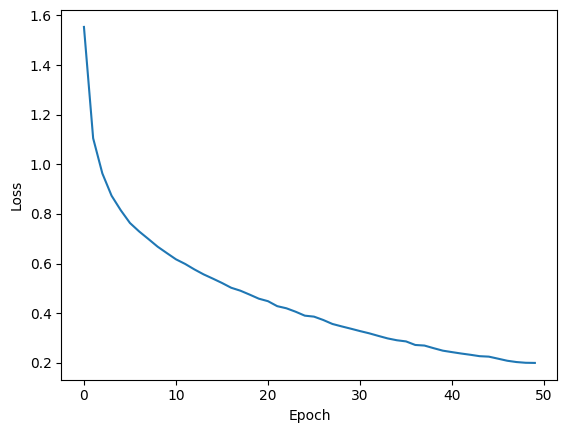

In [374]:
from matplotlib import pyplot as plt

plt.plot(range(len(loss_tape)), loss_tape)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [375]:
from sklearn.metrics import confusion_matrix

inf_test_loader = DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=True)
inf_x, inf_y, inf_l = next(iter(inf_test_loader))

rnn.eval()

with torch.inference_mode():
  inf_output = rnn(inf_x, inf_l)
  inf_output = inf_output.argmax(dim=1)
  print(inf_output, inf_y)
  cf_matrix = confusion_matrix(inf_y, inf_output)
  print(cf_matrix)

tensor([ 5,  1,  1,  ..., 15,  1, 14]) tensor([ 1,  1,  1,  ..., 15,  1,  1])
[[ 17   3   0   0   0   0   2   0   0   0   1   0   0   0   0   3   0   1]
 [  3 261   6   6   0   2   8  11   4   1   3   1   2   3  13  43   0   0]
 [  0   0  53   0   0   0   0   0   0   0   0   0   0   3   1  10   4   0]
 [  0  13   2  16   0   0   0   1   0   0   0   3   0   1   5  10   1   0]
 [  1   1   0   1   2   0   0   1   0   0   0   0   0   0   0   0   0   1]
 [  0   1   2   0   0   0   0   0   0   1   0   0   0   0   0   0   3   0]
 [  0   9   0   0   0   0  10   1   0   0   2   0   0   0   0   1   0   0]
 [  0   8   1   1   0   0   0  12   0   0   1   1   0   0   1   3   0   0]
 [  0   9   0   0   0   0   0   1   0   0   0   0   0   0   0   0   0   0]
 [  0   1   1   0   0   0   0   0   0  13   0   0   1   0   0   4   0   0]
 [  0   0   0   0   0   0   0   0   0   0 200   0   0   0   0   0   0   0]
 [  0   1   0   1   0   0   0   1   0   1   0   1   1   3   0   3   2   0]
 [  1   8   1   2   0 

<Axes: >

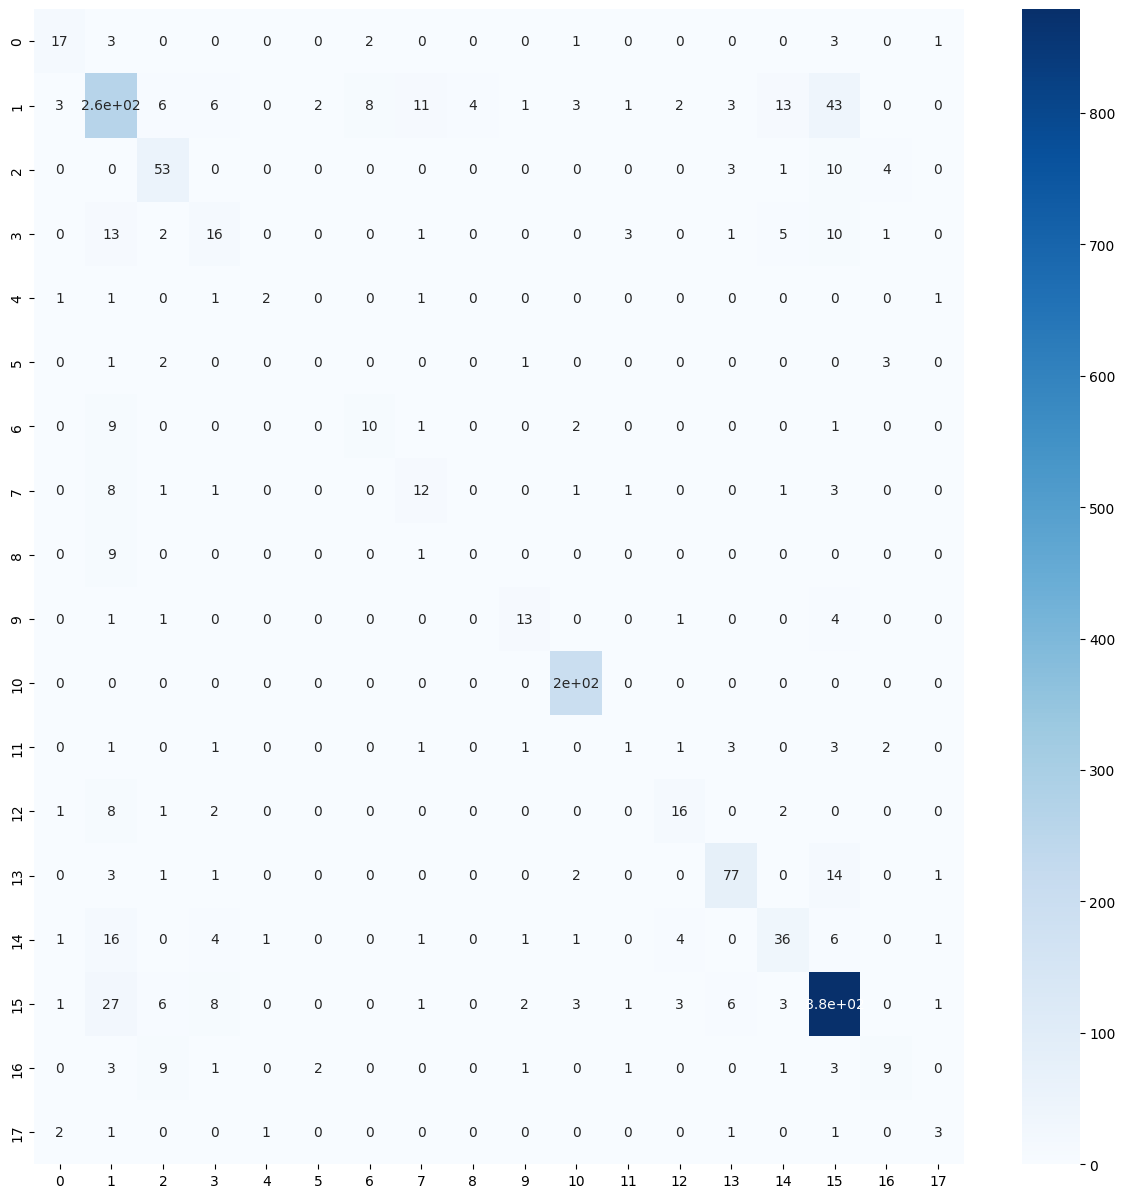

In [379]:
import seaborn as sns
plt.figure(figsize=(15, 15))
sns.heatmap(cf_matrix, annot=True, cmap="Blues")